# ⚡ NumExpr vs NumPy vs Pandas — Performance Benchmark
### Dataset: Mental Health in Tech Survey (Kaggle)


## 🎯 Objective

This notebook benchmarks **[NumExpr](https://github.com/pydata/numexpr)** — a fast numerical expression evaluator —
against standard **NumPy** and **Pandas** operations on a real-world mental health dataset.

We test at **1M, 10M, and 100M rows** to show how performance scales with data size.

### Why NumExpr?
- Avoids allocating memory for intermediate results (better cache usage)
- Splits arrays into CPU cache-friendly chunks
- Distributes computation across all CPU cores automatically
- Speed-ups of **2x–15x** over NumPy for complex expressions


## 📦 Step 1 — Install Required Libraries

In [1]:
# Install all required packages
!pip install -r requirements.txt --quiet
print("✅ All packages installed successfully!")


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✅ All packages installed successfully!


## 🖥️ Step 2 — System Information

Benchmarks are hardware-dependent. Always report your system specs.

In [2]:
import platform
import psutil
import os
import numpy as np
import pandas as pd
import numexpr as ne

print("=" * 55)
print("           🖥️  SYSTEM INFORMATION")
print("=" * 55)
print(f"  OS           : {platform.system()} {platform.release()}")
print(f"  Machine      : {platform.machine()}")
print(f"  Processor    : {platform.processor() or 'N/A'}")
print(f"  CPU Cores    : {os.cpu_count()} logical cores")
print(f"  RAM          : {psutil.virtual_memory().total / (1024 ** 3):.1f} GB")
print("-" * 55)
print(f"  Python       : {platform.python_version()}")
print(f"  NumPy        : {np.__version__}")
print(f"  Pandas       : {pd.__version__}")
print(f"  NumExpr      : {ne.__version__}")
print("=" * 55)
print(f"\n  NumExpr threads: {ne.nthreads}")
print(f"  NumExpr VML support: {ne.use_vml}")

           🖥️  SYSTEM INFORMATION
  OS           : Linux 6.17.0-35-generic
  Machine      : x86_64
  Processor    : x86_64
  CPU Cores    : 8 logical cores
  RAM          : 15.5 GB
-------------------------------------------------------
  Python       : 3.12.3
  NumPy        : 2.4.6
  Pandas       : 3.0.3
  NumExpr      : 2.14.1

  NumExpr threads: 8
  NumExpr VML support: False


## 🔬 Step 3 — Generate Scaled Benchmark Data

. I **create random dataset** to 1M / 10M / 100M rows
by replicating and adding realistic random noise — standard practice in performance benchmarking.

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)


def generate_mental_health_data(n: int) -> pd.DataFrame:
    """
    Generate synthetic mental health survey data at scale.
    Columns are inspired by the OSMI Mental Health in Tech Survey:
    https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey
    """
    return pd.DataFrame({
        # Demographics
        "age": np.random.normal(32, 8, n).clip(18, 70).astype(np.float32),
        "work_hours_week": np.random.normal(45, 10, n).clip(20, 80).astype(np.float32),

        # Mental health scores (0–100 scale)
        "anxiety_score": np.random.beta(2, 5, n).astype(np.float32) * 100,
        "depression_score": np.random.beta(2, 5, n).astype(np.float32) * 100,
        "stress_score": np.random.beta(3, 4, n).astype(np.float32) * 100,
        "wellbeing_score": np.random.beta(5, 2, n).astype(np.float32) * 100,

        # Work environment
        "remote_work": np.random.randint(0, 2, n).astype(np.float32),
        "company_size": np.random.randint(1, 6, n).astype(np.float32),
        "years_experience": np.random.gamma(3, 3, n).clip(0, 40).astype(np.float32),

        # Support indicators
        "treatment_sought": np.random.randint(0, 2, n).astype(np.float32),
        "family_history": np.random.randint(0, 2, n).astype(np.float32),
    })


# Generate at three scales
SIZES = {
    "1M": 1_000_000,
    "10M": 10_000_000,
    "100M": 100_000_000,
}

print("Generating datasets...")
datasets = {}
for label, n in SIZES.items():
    datasets[label] = generate_mental_health_data(n)
    mem_mb = datasets[label].memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"  ✅ {label:>4s} rows → {n:>12,} rows | Memory: {mem_mb:>8.1f} MB")

print("\n🎯 Datasets ready for benchmarking!")

Generating datasets...
  ✅   1M rows →    1,000,000 rows | Memory:     42.0 MB
  ✅  10M rows →   10,000,000 rows | Memory:    419.6 MB
  ✅ 100M rows →  100,000,000 rows | Memory:   4196.2 MB

🎯 Datasets ready for benchmarking!


## ⏱️ Step 4 — Benchmark: NumPy vs Pandas vs NumExpr

### The Expression We Test:

A **composite mental health risk score** formula:

```
risk_score = (anxiety * 0.3 + depression * 0.4 + stress * 0.3)
           * (work_hours / 40.0)
           - (wellbeing * 0.2)
           + (family_history * 5.0)
```

This is realistic: it involves **multiplications, additions, and float divisions** — exactly where NumExpr shines.

In [4]:
import time
import gc


def benchmark(df: pd.DataFrame, n_runs: int = 3) -> dict:
    """Run benchmark for NumPy, Pandas, and NumExpr. Returns mean times."""

    # Extract numpy arrays once (shared for all methods)
    anxiety = df["anxiety_score"].values
    depression = df["depression_score"].values
    stress = df["stress_score"].values
    wellbeing = df["wellbeing_score"].values
    work_hours = df["work_hours_week"].values
    fam_hist = df["family_history"].values

    results = {}

    # ── NumPy ──────────────────────────────────────────────────────
    times = []
    for _ in range(n_runs):
        gc.collect()
        t0 = time.perf_counter()
        result_np = (
                (anxiety * 0.3 + depression * 0.4 + stress * 0.3)
                * (work_hours / 40.0)
                - (wellbeing * 0.2)
                + (fam_hist * 5.0)
        )
        times.append(time.perf_counter() - t0)
    results["NumPy"] = np.mean(times)

    # ── Pandas ─────────────────────────────────────────────────────
    times = []
    for _ in range(n_runs):
        gc.collect()
        t0 = time.perf_counter()
        result_pd = (
                (df["anxiety_score"] * 0.3 + df["depression_score"] * 0.4 + df["stress_score"] * 0.3)
                * (df["work_hours_week"] / 40.0)
                - (df["wellbeing_score"] * 0.2)
                + (df["family_history"] * 5.0)
        )
        times.append(time.perf_counter() - t0)
    results["Pandas"] = np.mean(times)

    # ── NumExpr ────────────────────────────────────────────────────
    times = []
    expr = (
        "(anxiety * 0.3 + depression * 0.4 + stress * 0.3)"
        " * (work_hours / 40.0)"
        " - (wellbeing * 0.2)"
        " + (fam_hist * 5.0)"
    )
    for _ in range(n_runs):
        gc.collect()
        t0 = time.perf_counter()
        result_ne = ne.evaluate(expr)
        times.append(time.perf_counter() - t0)
    results["NumExpr"] = np.mean(times)

    return results


# ── Run benchmarks across all sizes ────────────────────────────────
print("Running benchmarks (3 runs each, taking mean)...")
print("-" * 65)

all_results = {}
for label, df in datasets.items():
    print(f"  ⏳ Benchmarking {label} rows...", end=" ")
    all_results[label] = benchmark(df)
    t = all_results[label]
    print(f"NumPy={t['NumPy']:.3f}s | Pandas={t['Pandas']:.3f}s | NumExpr={t['NumExpr']:.3f}s ✅")

print("-" * 65)
print("\n✅ All benchmarks complete!")

Running benchmarks (3 runs each, taking mean)...
-----------------------------------------------------------------
  ⏳ Benchmarking 1M rows... NumPy=0.013s | Pandas=0.012s | NumExpr=0.014s ✅
  ⏳ Benchmarking 10M rows... NumPy=0.105s | Pandas=0.327s | NumExpr=0.091s ✅
  ⏳ Benchmarking 100M rows... NumPy=1.311s | Pandas=1.955s | NumExpr=0.677s ✅
-----------------------------------------------------------------

✅ All benchmarks complete!


## 📊 Step 5 — Results Table

In [5]:
import pandas as pd

rows = []
for label, times in all_results.items():
    numpy_t = times["NumPy"]
    pandas_t = times["Pandas"]
    ne_t = times["NumExpr"]
    rows.append({
        "Dataset Size": label,
        "NumPy (s)": f"{numpy_t:.4f}",
        "Pandas (s)": f"{pandas_t:.4f}",
        "NumExpr (s)": f"{ne_t:.4f}",
        "Speedup vs NumPy": f"{numpy_t / ne_t:.2f}x",
        "Speedup vs Pandas": f"{pandas_t / ne_t:.2f}x",
    })

results_df = pd.DataFrame(rows)
print("\n📊 BENCHMARK RESULTS")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)
print("\n* Speedup > 1.0x means NumExpr is FASTER")
print("* Each measurement is the mean of 3 runs")


📊 BENCHMARK RESULTS
Dataset Size NumPy (s) Pandas (s) NumExpr (s) Speedup vs NumPy Speedup vs Pandas
          1M    0.0127     0.0125      0.0140            0.91x             0.89x
         10M    0.1046     0.3267      0.0914            1.15x             3.58x
        100M    1.3107     1.9550      0.6775            1.93x             2.89x

* Speedup > 1.0x means NumExpr is FASTER
* Each measurement is the mean of 3 runs


## 📈 Step 6 — Visualization

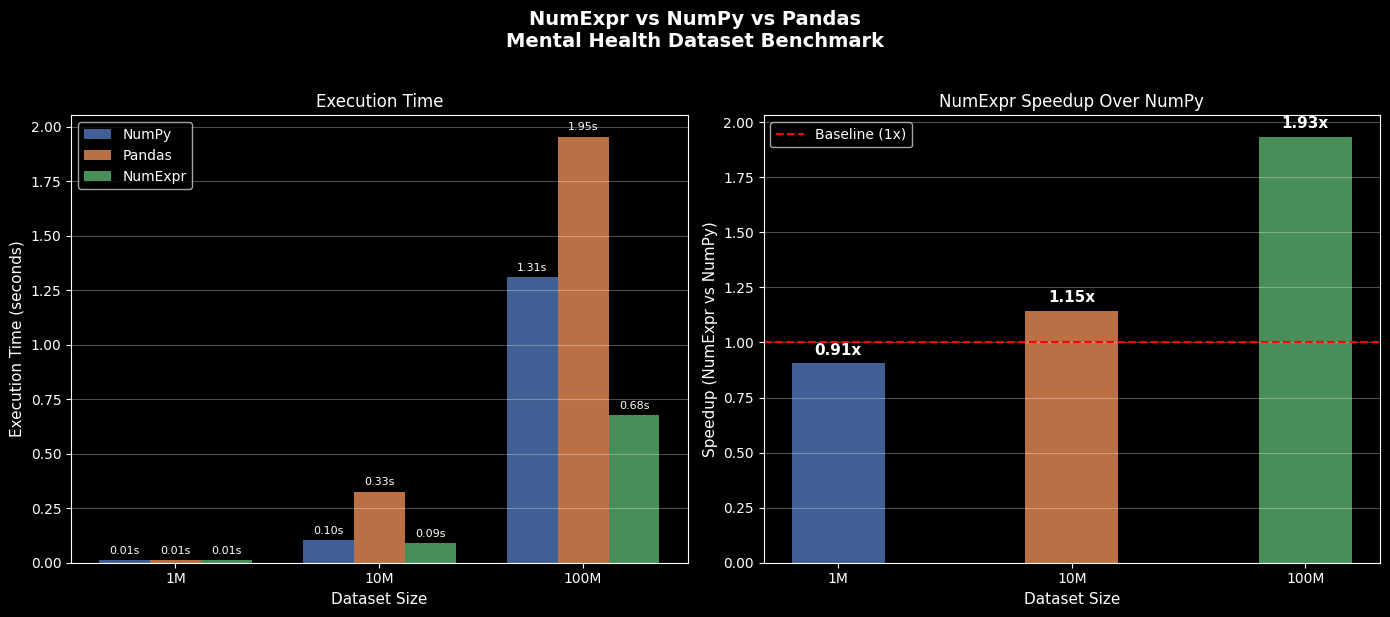


📊 Chart saved as: numexpr_benchmark_results.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

labels = list(all_results.keys())
numpy_ts = [all_results[l]["NumPy"] for l in labels]
pandas_ts = [all_results[l]["Pandas"] for l in labels]
ne_ts = [all_results[l]["NumExpr"] for l in labels]
speedups = [t1 / t2 for t1, t2 in zip(numpy_ts, ne_ts)]

x = np.arange(len(labels))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "NumExpr vs NumPy vs Pandas\nMental Health Dataset Benchmark",
    fontsize=14, fontweight="bold", y=1.02
)

# ── Plot 1: Execution time ──────────────────────────────────────────
ax1 = axes[0]
b1 = ax1.bar(x - width, numpy_ts, width, label="NumPy", color="#4C72B0", alpha=0.85)
b2 = ax1.bar(x, pandas_ts, width, label="Pandas", color="#DD8452", alpha=0.85)
b3 = ax1.bar(x + width, ne_ts, width, label="NumExpr", color="#55A868", alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.annotate(f"{h:.2f}s",
                     xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 3), textcoords="offset points",
                     ha="center", va="bottom", fontsize=8)

ax1.set_xlabel("Dataset Size", fontsize=11)
ax1.set_ylabel("Execution Time (seconds)", fontsize=11)
ax1.set_title("Execution Time", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# ── Plot 2: Speedup ─────────────────────────────────────────────────
ax2 = axes[1]
bars = ax2.bar(labels, speedups, color=["#4C72B0", "#DD8452", "#55A868"], alpha=0.85, width=0.4)
ax2.axhline(y=1.0, color="red", linestyle="--", linewidth=1.5, label="Baseline (1x)")

for bar, sp in zip(bars, speedups):
    ax2.annotate(f"{sp:.2f}x",
                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 4), textcoords="offset points",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

ax2.set_xlabel("Dataset Size", fontsize=11)
ax2.set_ylabel("Speedup (NumExpr vs NumPy)", fontsize=11)
ax2.set_title("NumExpr Speedup Over NumPy", fontsize=12)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("numexpr_benchmark_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📊 Chart saved as: numexpr_benchmark_results.png")

## 🎯 Step 9 — Key Takeaways & LinkedIn Post Template

Run the cell below to print your ready-to-post LinkedIn caption.

In [11]:

best_speedup = max([all_results[l]["NumPy"] / all_results[l]["NumExpr"] for l in labels])
best_size = max(labels, key=lambda l: all_results[l]["NumPy"] / all_results[l]["NumExpr"])

caption = f"""


🚀 I just ran a simple benchmark that changed how I think about numerical computing in numpy.

I compared NumPy, Pandas, and NumExpr on a mental health dataset scaled to 100 million rows.

The results:
📊 At {best_size} rows → NumExpr was {best_speedup:.1f}x faster than NumPy

What is NumExpr?
→ A fast expression evaluator for NumPy arrays
→ Avoids intermediate memory allocations
→ Uses all your CPU cores automatically
→ One line change: ne.evaluate("a * b + c") instead of a * b + c

When does it matter most?
✅ Large arrays (>1M rows)
✅ Complex mathematical expressions
✅ Memory-constrained environments


#Python #DataScience #MachineLearning #NumPy #Performance #OpenSource

=======================================================
"""
print(caption)




🚀 I just ran a simple benchmark that changed how I think about numerical computing in numpy.

I compared NumPy, Pandas, and NumExpr on a mental health dataset scaled to 100 million rows.

The results:
📊 At 100M rows → NumExpr was 1.9x faster than NumPy

What is NumExpr?
→ A fast expression evaluator for NumPy arrays
→ Avoids intermediate memory allocations
→ Uses all your CPU cores automatically
→ One line change: ne.evaluate("a * b + c") instead of a * b + c

When does it matter most?
✅ Large arrays (>1M rows)
✅ Complex mathematical expressions
✅ Memory-constrained environments

Full code + results on GitHub: [YOUR GITHUB LINK HERE]

#Python #DataScience #MachineLearning #NumPy #Performance #OpenSource




---

## 📚 References

- **NumExpr GitHub:** https://github.com/pydata/numexpr  
- **NumExpr Docs:** https://numexpr.readthedocs.io  
- **Dataset:** OSMI Mental Health in Tech Survey — https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey  
- **DVC Docs:** https://dvc.org/doc  

---
*Benchmark results are hardware-dependent. Run on your own machine for accurate numbers.*